<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Cristian Jara
- Nombre de alumno 2: Felipe Fierro

### **Link de repositorio de GitHub:** [https://github.com/cristianjaram/MDS7202-labs.git](https://github.com/cristianjaram/MDS7202-labs.git)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [ ]:
# # Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
# try:
#     from google.colab import drive
#     drive.mount("/content/drive")
#     path = 'Dirección donde tiene los archivos en el Drive'
# except:
#     print('Ignorando conexión drive-colab')

In [2]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [3]:
df = pd.read_csv('energia_homero.csv')
df['date'] = pd.to_datetime(df['date'])

# Visualización del consumo
px.line(df, x='date', y='Energy_kWh', title='Consumo energético diario - Homero Simpson').show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]

R: Sí, se ve un comportamiento estacional en julio.

4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

R: La estimación se ajusta mejor a las observaciones reales y se logra capturar mejor la estacionalidad de los datos.

**Respuesta**

In [4]:
# 0. Conjunto de entrenamiento y prueba
train = df[df['date'] < '2020-03-01'].copy()
test = df[df['date'] >= '2020-03-01'].copy()

In [5]:
# 1. Pipeline para tendencia
class DateTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.start_date = X['date'].min()
        return self
    def transform(self, X):
        X_ = pd.DataFrame()
        X_['days'] = (X['date'] - self.start_date).dt.days
        return X_

Pipeline_trend = Pipeline([
    ('date', DateTransformer()),
    ('model', LinearRegression())
])

In [6]:
# 2. Entrenamiento y predicción tendencia
Pipeline_trend.fit(train[['date']], train['Energy_kWh'])
train_pred = Pipeline_trend.predict(train[['date']])
test_pred = Pipeline_trend.predict(test[['date']])

mae_train = mean_absolute_error(train['Energy_kWh'], train_pred)
mae_test = mean_absolute_error(test['Energy_kWh'], test_pred)
print(f'MAE Entrenamiento (Tendencia): {mae_train:.3f}')
print(f'MAE Prueba (Tendencia): {mae_test:.3f}')

# Gráfica de predicciones
px.line(pd.concat([
    pd.DataFrame({'date': train['date'], 'Real': train['Energy_kWh'], 'Pred': train_pred}),
    pd.DataFrame({'date': test['date'], 'Real': test['Energy_kWh'], 'Pred': test_pred})
]), x='date', y=['Real', 'Pred'], title='Predicciones - Modelo de Tendencia').show()

MAE Entrenamiento (Tendencia): 10.568
MAE Prueba (Tendencia): 8.656


In [8]:
# 3. Gráfico del error
error = df.copy()
error['pred'] = np.concatenate([train_pred, test_pred])
error['resid'] = error['Energy_kWh'] - error['pred']
px.line(error, x='date', y='resid', title='Error (Valor real - Valor predicho)').show()

In [9]:
# 4. Pipeline para estacionalidad (Fourier)
class FourierFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, period=365.25, n=5):
        self.period = period
        self.n = n
    def fit(self, X, y=None):
        self.start_date = X['date'].min()
        return self
    def transform(self, X):
        t = (X['date'] - self.start_date).dt.days.values
        X_ = pd.DataFrame()
        for k in range(1, self.n + 1):
            X_[f'sin_{k}'] = np.sin(2 * np.pi * k * t / self.period)
            X_[f'cos_{k}'] = np.cos(2 * np.pi * k * t / self.period)
        return X_

P = 365.25  # periodo anual
n = 8        # número de términos Fourier
Pipeline_seasonal = Pipeline([
    ('fourier', FourierFeatures(period=P, n=n)),
    ('model', LinearRegression())
])

In [10]:
# 5. Entrenamiento modelo estacional
Pipeline_seasonal.fit(train[['date']], train['Energy_kWh'])
train_pred_s = Pipeline_seasonal.predict(train[['date']])
test_pred_s = Pipeline_seasonal.predict(test[['date']])

mae_train_s = mean_absolute_error(train['Energy_kWh'], train_pred_s)
mae_test_s = mean_absolute_error(test['Energy_kWh'], test_pred_s)
print(f'MAE Entrenamiento (Estacional): {mae_train_s:.3f}')
print(f'MAE Prueba (Estacional): {mae_test_s:.3f}')

# Gráfica predicciones estacionales
px.line(pd.concat([
    pd.DataFrame({'date': train['date'], 'Real': train['Energy_kWh'], 'Pred': train_pred_s}),
    pd.DataFrame({'date': test['date'], 'Real': test['Energy_kWh'], 'Pred': test_pred_s})
]), x='date', y=['Real', 'Pred'], title='Predicciones - Modelo Estacional (Fourier)').show()

MAE Entrenamiento (Estacional): 5.354
MAE Prueba (Estacional): 4.331


In [11]:
# 6. Error estacional
error_s = df.copy()
error_s['pred'] = np.concatenate([train_pred_s, test_pred_s])
error_s['resid'] = error_s['Energy_kWh'] - error_s['pred']
px.line(error_s, x='date', y='resid', title='Error - Modelo Estacional (Fourier)').show()

print("\n¿Hay comportamiento estacional? Si el error muestra un patrón periódico, la serie presenta estacionalidad.")


¿Hay comportamiento estacional? Si el error muestra un patrón periódico, la serie presenta estacionalidad.


## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

R: Aún se alcanza a ver un comportamiento estacional en julio, aunque mucho menos notorio que en la parte anterior.

In [12]:
# librerias extras
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.metrics import mean_absolute_error
from prophet import Prophet

c:\Users\Felipe\Desktop\Lab MDS\lab_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



**Respuesta:**

In [13]:
# 1. Carga de datos
df = pd.read_csv('energia_homero.csv')
df['date'] = pd.to_datetime(df['date'])

# Separar conjuntos de entrenamiento y prueba
train = df[df['date'] < '2020-03-01'].copy()
test = df[df['date'] >= '2020-03-01'].copy()

# Renombrar variables para Prophet
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

In [14]:
# 2. Crear y ajustar modelo Prophet
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(train)


# Crear dataframe futuro para predicciones en el conjunto de prueba
future = test[['ds']].copy()
forecast = m.predict(future)

23:24:57 - cmdstanpy - INFO - Chain [1] start processing
23:24:58 - cmdstanpy - INFO - Chain [1] done processing


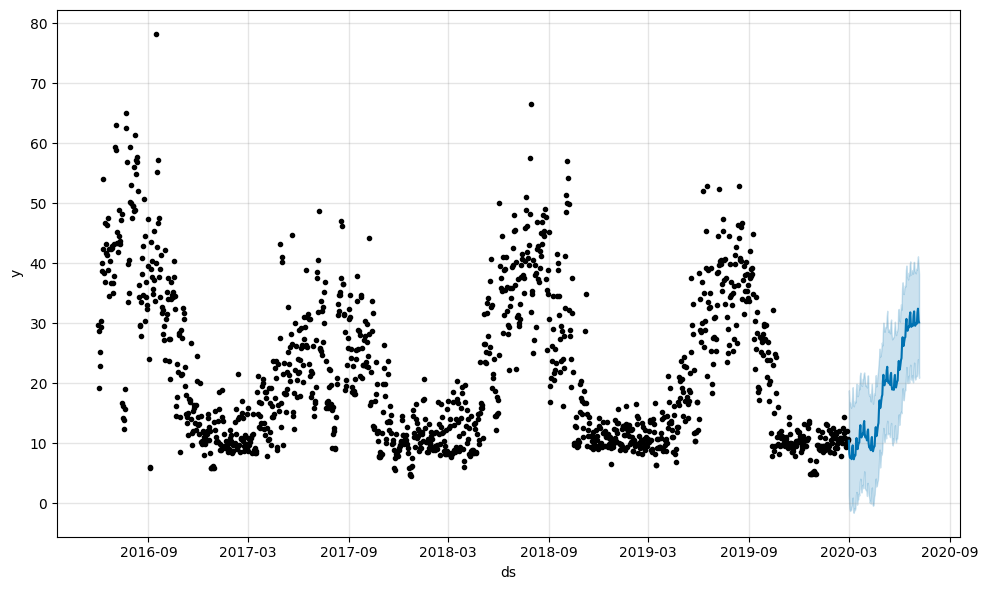

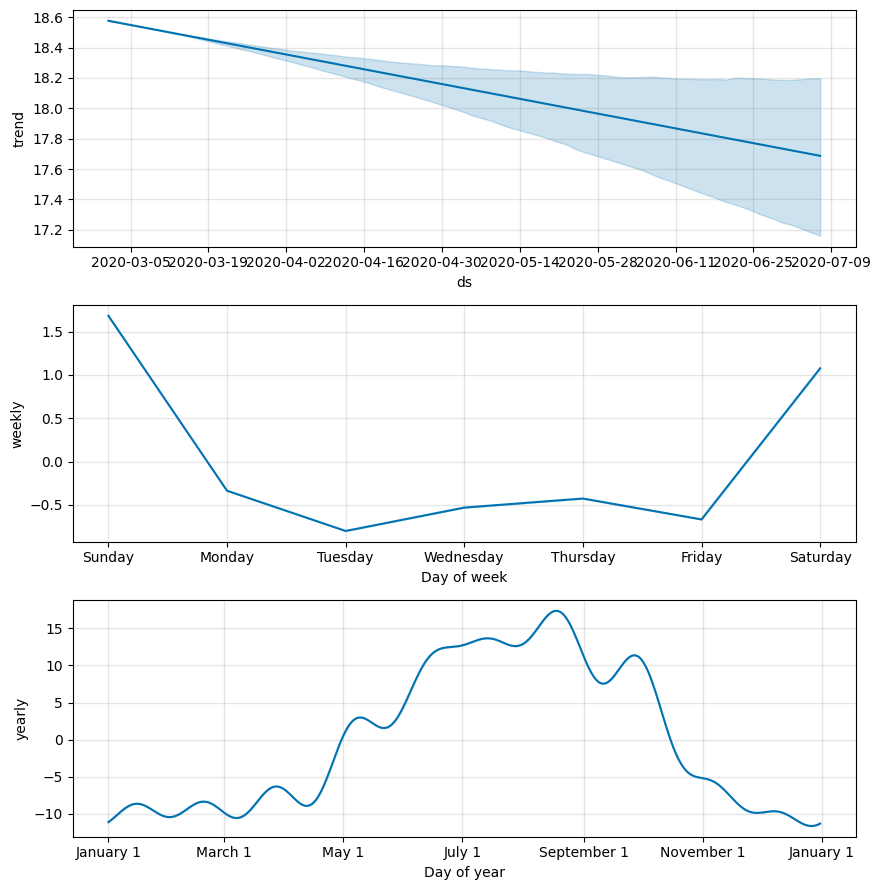

In [15]:
# 3. Gráficos de predicción y componentes
fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

In [16]:
# 4. Calcular MAE en entrenamiento y prueba
# Predicciones sobre el conjunto de entrenamiento
forecast_train = m.predict(train[['ds']])
mae_train = mean_absolute_error(train['y'], forecast_train['yhat'])


# Predicciones sobre el conjunto de prueba
mae_test = mean_absolute_error(test['y'], forecast['yhat'])


print(f"MAE Entrenamiento (Prophet): {mae_train:.3f}")
print(f"MAE Prueba (Prophet): {mae_test:.3f}")

MAE Entrenamiento (Prophet): 4.820
MAE Prueba (Prophet): 4.934


In [18]:
# 5. Graficar error (Valor real - Valor predicho)
error_df = pd.concat([
train[['ds', 'y']],
test[['ds', 'y']]
]).reset_index(drop=True)


error_df['yhat'] = pd.concat([
forecast_train['yhat'],
forecast['yhat']
]).values


error_df['error'] = error_df['y'] - error_df['yhat']
px.line(error_df, x='ds', y='error', title='Error (Valor real - Valor predicho) con Prophet').show()

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

R: El comportamiento estacional no se alcanza a apreciar notoriamente en este caso. Las variables usadas como regresores ayudan a capturar esta estacionalidad e influyen en el comportamiento del consumo del hogar de Homero, permiten realizar estimiaciones más precisas.

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

In [19]:
# 0. Carga de datos principales
df = pd.read_csv('energia_homero.csv')
df['date'] = pd.to_datetime(df['date'])

# Carga de datos meteorológicos del Profesor Frink
datos_clima = pd.read_csv('datos_frink.csv')
datos_clima['date'] = pd.to_datetime(datos_clima['date'])

# Unir datasets por fecha
df = df.merge(datos_clima, on='date', how='left')

# División en entrenamiento y prueba
train = df[df['date'] < '2020-03-01'].copy()
test = df[df['date'] >= '2020-03-01'].copy()

# Renombrar columnas para Prophet
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

# 0. Selección de regresores relevantes (temperaturas, humedad y viento)
regresores = ['Temp_avg', 'Hum_avg', 'Wind_avg']
print(f"Variables exógenas seleccionadas: {regresores}")

Variables exógenas seleccionadas: ['Temp_avg', 'Hum_avg', 'Wind_avg']


In [20]:
# 1. Crear modelo Prophet e incluir regresores
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
for r in regresores:
    m.add_regressor(r)

# Entrenar modelo
m.fit(train[['ds', 'y'] + regresores])

23:26:04 - cmdstanpy - INFO - Chain [1] start processing
23:26:05 - cmdstanpy - INFO - Chain [1] done processing


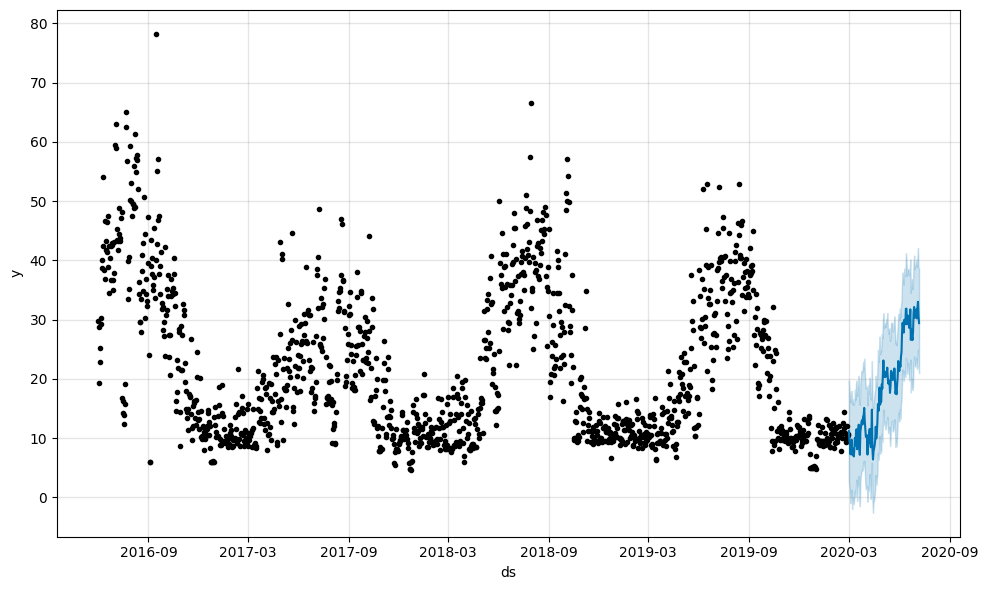

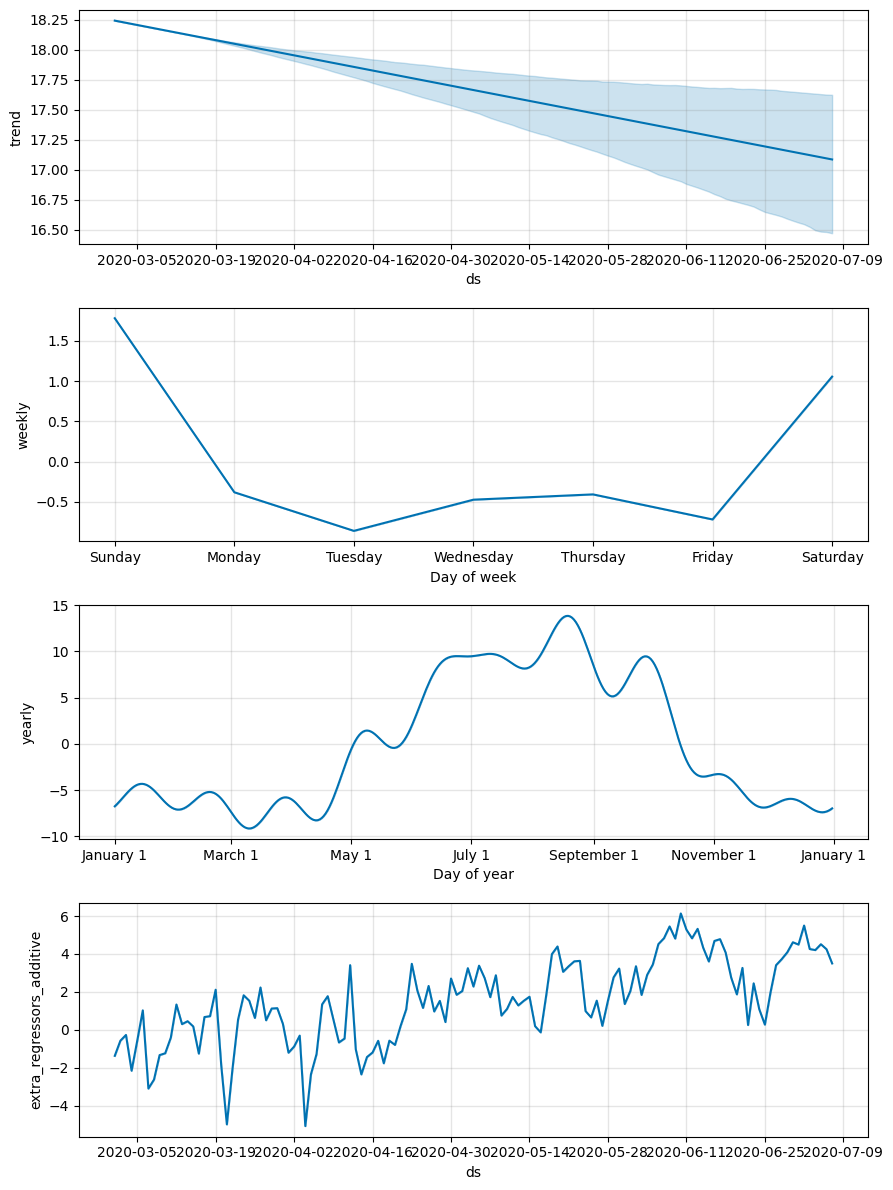

In [21]:
# 2. Realizar predicciones sobre el conjunto de prueba
forecast = m.predict(test[['ds'] + regresores])

# Graficar resultados
fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)

In [22]:
# 3. Calcular MAE en entrenamiento y prueba
forecast_train = m.predict(train[['ds'] + regresores])
mae_train = mean_absolute_error(train['y'], forecast_train['yhat'])
mae_test = mean_absolute_error(test['y'], forecast['yhat'])

print(f"MAE Entrenamiento (Prophet + Regresores): {mae_train:.3f}")
print(f"MAE Prueba (Prophet + Regresores): {mae_test:.3f}")

MAE Entrenamiento (Prophet + Regresores): 4.754
MAE Prueba (Prophet + Regresores): 4.523


In [23]:
# 4. Análisis de errores
error_df = pd.concat([
    train[['ds', 'y']],
    test[['ds', 'y']]
]).reset_index(drop=True)

error_df['yhat'] = pd.concat([
    forecast_train['yhat'],
    forecast['yhat']
]).values

error_df['error'] = error_df['y'] - error_df['yhat']
px.line(error_df, x='ds', y='error', title='Error (Valor real - Valor predicho) con Prophet y Regresores').show()

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]

R: El MAE mejora respecto al modelo sin lags, por lo que humedad y viento aportan información predictiva. El error muestra menor estacionalidad, el modelo ha logrado incorporar parte del efecto retardado de las variables climáticas.


**Respuesta:**

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf

In [28]:
# 0. Carga de datos
energia = pd.read_csv('energia_homero.csv')
energia['date'] = pd.to_datetime(energia['date'])


clima = pd.read_csv('datos_frink.csv')
clima['date'] = pd.to_datetime(clima['date'])


# Merge
df = energia.merge(clima, on='date', how='left')


# División entrenamiento / prueba
train = df[df['date'] < '2020-03-01'].copy()
test = df[df['date'] >= '2020-03-01'].copy()


# Renombrar
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

<Figure size 600x300 with 0 Axes>

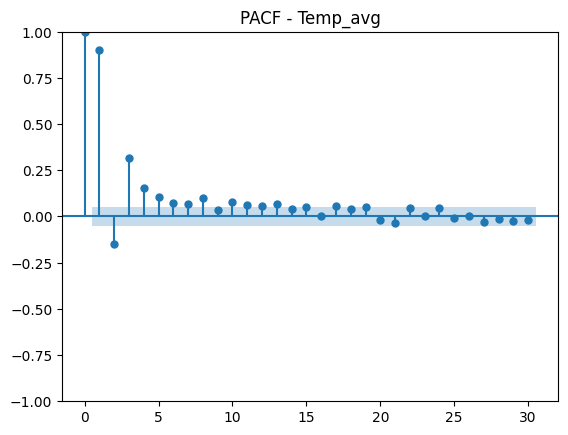

<Figure size 600x300 with 0 Axes>

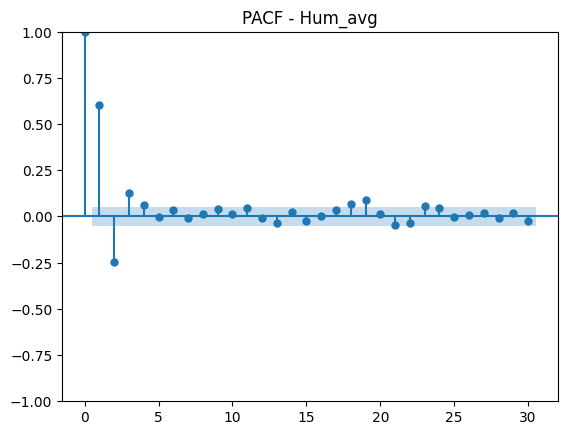

<Figure size 600x300 with 0 Axes>

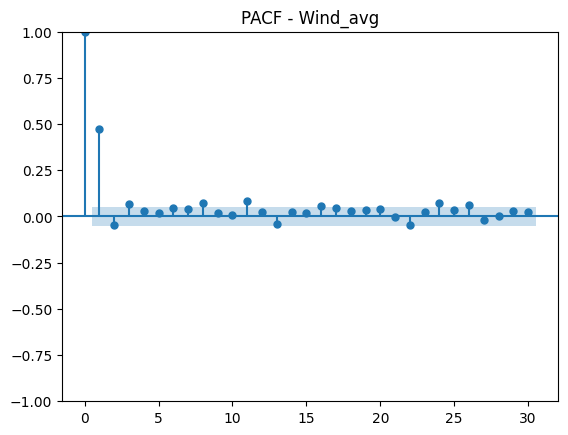

Se puede observar que los lags 1 y 2 tienen correlación significativa en la mayoría de las variables, por lo que se utilizarán lags=1 y lags=2.


In [31]:
# 1. Calcular Autocorrelación Parcial para las variables 'avg'
variables_avg = ['Temp_avg', 'Hum_avg', 'Wind_avg']


for var in variables_avg:
    plt.figure(figsize=(6,3))
    plot_pacf(train[var], lags=30, method='ywm')
    plt.title(f'PACF - {var}')
    plt.show()


print("Se puede observar que los lags 1 y 2 tienen correlación significativa en la mayoría de las variables, por lo que se utilizarán lags=1 y lags=2.")

In [32]:
# 2. Crear Lags (1 y 2)
for var in variables_avg:
    for lag in [1, 2]:
        train[f'{var}_lag{lag}'] = train[var].shift(lag)
        test[f'{var}_lag{lag}'] = test[var].shift(lag)

In [33]:
# 3. Imputar nulos con la media
for col in [c for c in train.columns if 'lag' in c]:
    train[col].fillna(train[col].mean(), inplace=True)
    test[col].fillna(train[col].mean(), inplace=True)

C:\Users\Felipe\AppData\Local\Temp\ipykernel_20076\3270079581.py:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Felipe\AppData\Local\Temp\ipykernel_20076\3270079581.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [34]:
# 4. Crear y entrenar modelo Prophet con regresores y lags
regresores = variables_avg + [c for c in train.columns if 'lag' in c]


m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
for r in regresores:
    m.add_regressor(r)


m.fit(train[['ds', 'y'] + regresores])


# Predicciones
y_pred_test = m.predict(test[['ds'] + regresores])
y_pred_train = m.predict(train[['ds'] + regresores])

23:29:11 - cmdstanpy - INFO - Chain [1] start processing
23:29:11 - cmdstanpy - INFO - Chain [1] done processing


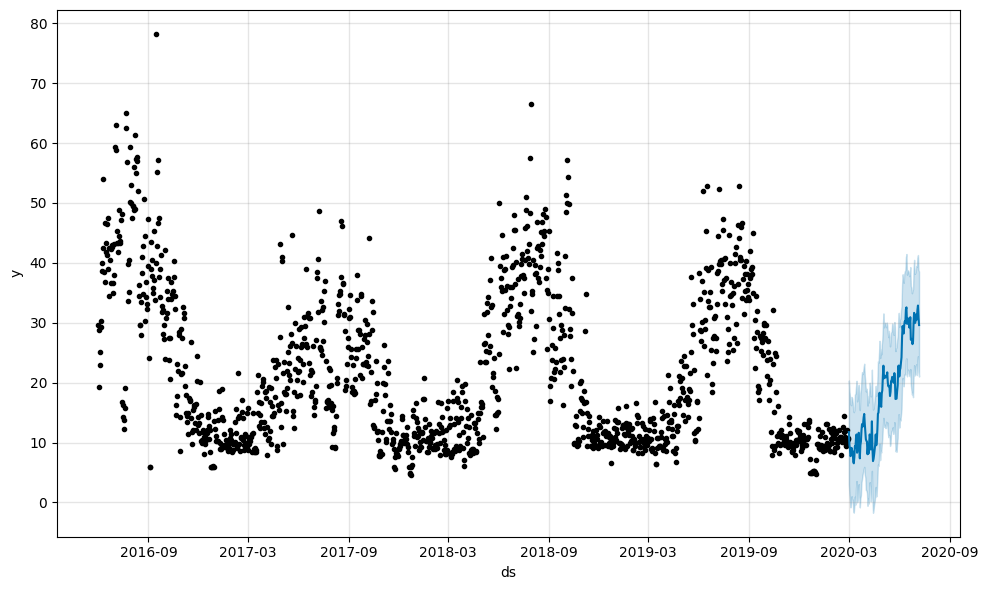

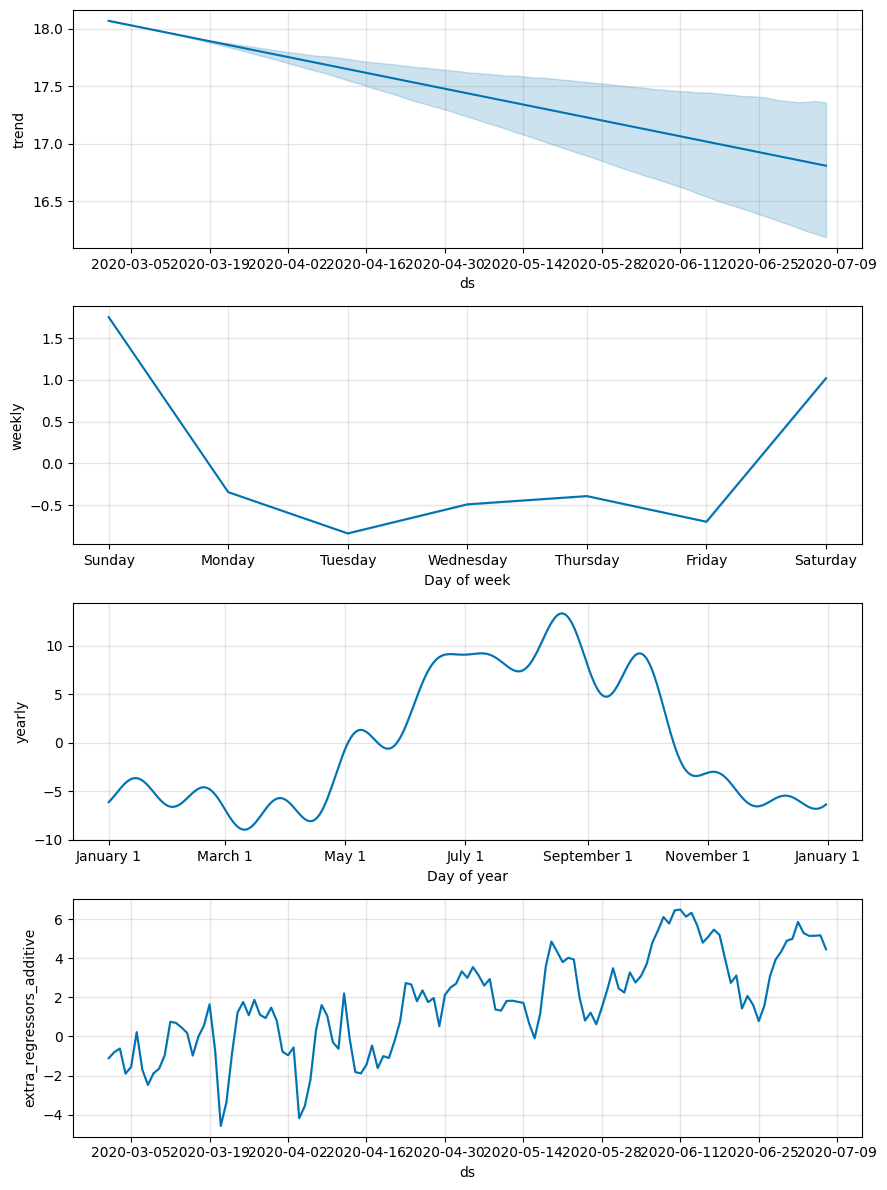

In [35]:
# 5. Graficar predicciones y componentes
fig1 = m.plot(y_pred_test)
fig2 = m.plot_components(y_pred_test)

In [36]:
# 6. Calcular MAE
mae_train = mean_absolute_error(train['y'], y_pred_train['yhat'])
mae_test = mean_absolute_error(test['y'], y_pred_test['yhat'])
print(f"MAE Entrenamiento (Prophet + Lags): {mae_train:.3f}")
print(f"MAE Prueba (Prophet + Lags): {mae_test:.3f}")

MAE Entrenamiento (Prophet + Lags): 4.729
MAE Prueba (Prophet + Lags): 4.535


In [38]:
# 7. Graficar error
total = pd.concat([
train[['ds', 'y']],
test[['ds', 'y']]
]).reset_index(drop=True)


total['yhat'] = pd.concat([
y_pred_train['yhat'],
y_pred_test['yhat']
]).values
total['error'] = total['y'] - total['yhat']


px.line(total, x='ds', y='error', title='Error (Valor real - Valor predicho) con Prophet y Lags').show()

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]

R: Luego de optimizar, ya no se observa estacionalidad en los errores.


In [40]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [41]:
# 0. Carga y preparación de datos
energia = pd.read_csv('energia_homero.csv')
energia['date'] = pd.to_datetime(energia['date'])

clima = pd.read_csv('datos_frink.csv')
clima['date'] = pd.to_datetime(clima['date'])

# Merge
df = energia.merge(clima, on='date', how='left')

# División entrenamiento / prueba
train = df[df['date'] < '2020-03-01'].copy()
test = df[df['date'] >= '2020-03-01'].copy()

# Renombrar para Prophet
train = train.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})
test = test.rename(columns={'date': 'ds', 'Energy_kWh': 'y'})

# Variables exógenas consideradas
features = ['Temp_avg', 'Hum_avg', 'Wind_avg']

In [42]:
# 2. Crear grilla de hiperparámetros
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 5.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9]
}

In [43]:
# 3. Ejecutar optimización
tuning_results, best_params = optimize_prophet(train, test, features, param_grid)
print("Mejores hiperparámetros encontrados:")
print(best_params)

Tuning Prophet parameters:   0%|          | 0/36 [00:00<?, ?it/s]

Tuning Prophet parameters: 100%|██████████| 36/36 [00:23<00:00,  1.52it/s]

Mejores hiperparámetros encontrados:
{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}


In [44]:
# 4. Entrenar modelo Prophet con los mejores parámetros
m = Prophet(**best_params)
for f in features:
    m.add_regressor(f)

m.fit(train[['ds', 'y'] + features])

# Predicciones
forecast_train = m.predict(train[['ds'] + features])
forecast_test = m.predict(test[['ds'] + features])

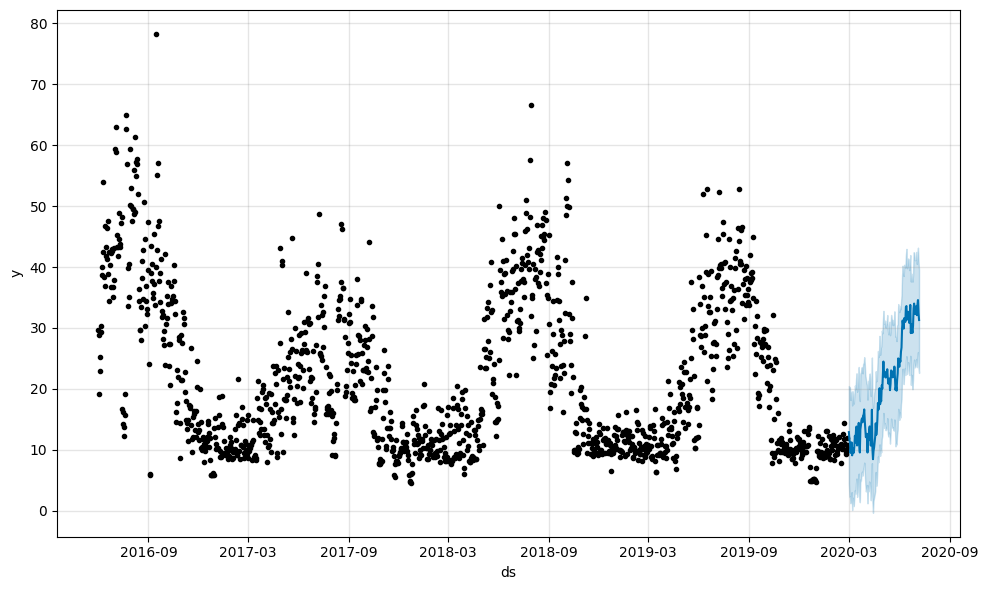

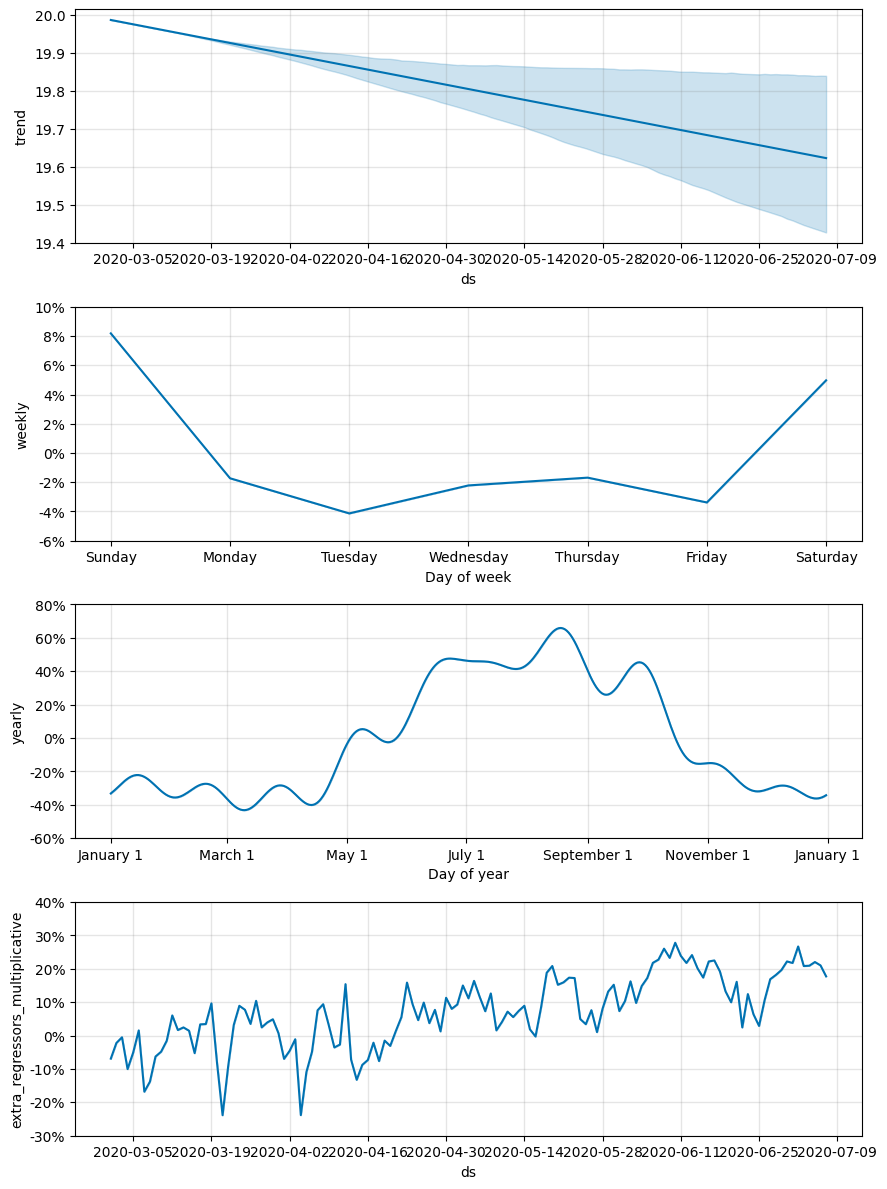

In [45]:
# 5. Graficar resultados
fig1 = m.plot(forecast_test)
fig2 = m.plot_components(forecast_test)

In [46]:
# 6. Calcular MAE
mae_train = mean_absolute_error(train['y'], forecast_train['yhat'])
mae_test = mean_absolute_error(test['y'], forecast_test['yhat'])

print(f"MAE Entrenamiento (Prophet Optimizado): {mae_train:.3f}")
print(f"MAE Prueba (Prophet Optimizado): {mae_test:.3f}")

MAE Entrenamiento (Prophet Optimizado): 4.860
MAE Prueba (Prophet Optimizado): 3.995


In [47]:
# 7. Graficar error
error_df = pd.concat([
    train[['ds', 'y']],
    test[['ds', 'y']]
]).reset_index(drop=True)

error_df['yhat'] = pd.concat([
    forecast_train['yhat'],
    forecast_test['yhat']
]).values

error_df['error'] = error_df['y'] - error_df['yhat']

px.line(error_df, x='ds', y='error', title='Error (Valor real - Valor predicho) - Prophet Optimizado').show()

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [ ]:
#!pip install surprise

In [48]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [49]:
df = pd.read_csv("cervezas.csv")

print("Primeras filas del dataset:")
display(df.head())

print("\nInformación general del dataset:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

print(f"\nNúmero total de evaluaciones: {len(df)}")
print(f"Número de usuarios únicos: {df['userId'].nunique()}")
print(f"Número de cervezas únicas: {df['beerId'].nunique()}")

Primeras filas del dataset:


,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA



Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB

Valores nulos por columna:
userId       0
beerId       0
rating       0
beerName     0
beerStyle    0
dtype: int64

Número total de evaluaciones: 295059
Número de usuarios únicos: 706
Número de cervezas únicas: 3747


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

In [50]:
# 2.1 Caracterización inicial

# Estadística descriptiva
print("\nEstadística descriptiva de las calificaciones:")
display(df['rating'].describe())

# Promedio de calificación por usuario
user_mean = df.groupby('userId')['rating'].mean().reset_index(name='mean_user_rating')
# Promedio de calificación por cerveza
beer_mean = df.groupby('beerName')['rating'].mean().reset_index(name='mean_beer_rating')

# Visualización
px.histogram(df, x='rating', nbins=20, title='Distribución de Calificaciones').show()

# Número de usuarios, productos, calificaciones faltantes
usuarios = df['userId'].nunique()
productos = df['beerId'].nunique()
total_calif = df.shape[0]
faltantes = df['rating'].isna().sum()

print(f"Usuarios únicos: {usuarios}")
print(f"Productos únicos: {productos}")
print(f"Calificaciones totales: {total_calif}")
print(f"Calificaciones faltantes: {faltantes}")
print(f"Media general de calificaciones: {df['rating'].mean():.2f}")

# Matriz usuario-producto
matriz = df.pivot_table(index='userId', columns='beerName', values='rating')
print("\nMatriz (usuario x cerveza):")
display(matriz.head())


Estadística descriptiva de las calificaciones:


count    295059.000000
mean          3.860367
std           0.702807
min           1.000000
25%           3.500000
50%           4.000000
75%           4.500000
max           5.000000
Name: rating, dtype: float64

Usuarios únicos: 706
Productos únicos: 3747
Calificaciones totales: 295059
Calificaciones faltantes: 0
Media general de calificaciones: 3.86

Matriz (usuario x cerveza):


beerName,"""Shabadoo"" Black & Tan Ale",# 100,#9,'t Gaverhopke Extra,'t Smisje Calva Reserva,(512) Pecan Porter,10 Commandments,10 Squared Fish Tale Ale,10.0,1000 IBU,...,Žatec,§ucaba (Abacus),Édition 2005,Éphémère (Apple),Éphémère (Cassis / Black Currant),Éphémère (Cranberry),Équinoxe Du Printemps,Ølfabrikken Porter,Über Pils,ÜberSun (Imperial Summer Wheat Beer)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [53]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [54]:
# 1. Crear DataFrame con características únicas de las cervezas
cervezas = df[['beerId', 'beerName', 'beerStyle']].drop_duplicates(subset='beerId').reset_index(drop=True)
print(f"\nTotal de cervezas únicas: {len(cervezas)}")


Total de cervezas únicas: 3747


In [55]:
# 2. Aplicar Bag of Words sobre la columna beerStyle
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=10
)

tfidf_matrix = vectorizer.fit_transform(cervezas['beerStyle'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nMatriz TF-IDF de estilos de cerveza:")
display(tfidf_df.head())


Matriz TF-IDF de estilos de cerveza:


,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.331506,0.0,0.0,0.307083,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.325434,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.450492,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.539989,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
# 3. Función para recomendar cervezas similares
def recomendar_cervezas(nombre_cerveza, n=5):
    """
    Retorna las n cervezas más similares según similitud coseno.
    """
    idx = cervezas[cervezas['beerName'].str.lower() == nombre_cerveza.lower()].index
    if len(idx) == 0:
        print("Cerveza no encontrada.")
        return
    idx = idx[0]
    sim_matrix = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    indices_similares = sim_matrix.argsort()[::-1][1:n+1]
    similares = cervezas.iloc[indices_similares][['beerName', 'beerStyle']]
    print(f"Top {n} cervezas similares a '{nombre_cerveza}':")
    display(similares)

# Ejemplo: cervezas similares a “Chocolate Porter”
recomendar_cervezas("Chocolate Porter")

Top 5 cervezas similares a 'Chocolate Porter':


,beerName,beerStyle
2475,Short's Black Cherry Porter,American Porter
837,Michelob Porter,American Porter
2303,Shastafarian Porter,American Porter
848,Smoke From The Oak (Bourbon Barrel Aged),American Porter
3027,Smoke From The Oak (Wine Barrel Aged),American Porter


In [57]:
# 4. Cervezas preferidas por Carl (userId = 100)
carl_ratings = df[df['userId'] == 100].sort_values(by='rating', ascending=False)
print("\nCervezas mejor evaluadas por Carl:")
display(carl_ratings.head(3))

mejor_cerveza_carl = carl_ratings.iloc[0]['beerName']
print(f"\nLa cerveza favorita de Carl es: {mejor_cerveza_carl}")
print("Cervezas recomendadas para Carl:")
recomendar_cervezas(mejor_cerveza_carl)


Cervezas mejor evaluadas por Carl:


,userId,beerId,rating,beerName,beerStyle
178444,100,325,4.5,McNeill's Firehouse Amber Ale,American Amber / Red Ale
44395,100,325,4.5,McNeill's Firehouse Amber Ale,American Amber / Red Ale
164471,100,325,4.5,McNeill's Firehouse Amber Ale,American Amber / Red Ale



La cerveza favorita de Carl es: McNeill's Firehouse Amber Ale
Cervezas recomendadas para Carl:
Top 5 cervezas similares a 'McNeill's Firehouse Amber Ale':


,beerName,beerStyle
3482,5 A.M. Saint,American Amber / Red Ale
1882,Captain Sig's Northwestern Ale,American Amber / Red Ale
1937,Red Tail Ale,American Amber / Red Ale
1972,Powder Hound Winter Ale,American Amber / Red Ale
673,Tröegs Hopback Amber Ale,American Amber / Red Ale


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [58]:
from surprise import Dataset, Reader, KNNBasic, accuracy
from surprise.model_selection import train_test_split
import pandas as pd

In [59]:
# 1. Transformación del DataFrame a Dataset de Surprise

# Surprise requiere solo: userId, beerId, rating
ratings = df[['userId', 'beerId', 'rating']]

# Rango de calificaciones (1 a 5 según el enunciado)
reader = Reader(rating_scale=(1, 5))

# Crear dataset de surprise
data = Dataset.load_from_df(ratings, reader)

In [60]:
# 2. División en entrenamiento y prueba (30% test)

trainset, testset = train_test_split(data, test_size=0.3, random_state=42)

In [61]:
# 3. Modelo KNN basado en usuarios (similitud coseno)

sim_user = {
    'name': 'cosine',
    'user_based': True  # basado en usuarios
}

model_user = KNNBasic(sim_options=sim_user)
model_user.fit(trainset)

# Predicciones en el conjunto de prueba
pred_user = model_user.test(testset)

# MAE
mae_user = accuracy.mae(pred_user)

# Mostrar algunas predicciones
pred_df_user = pd.DataFrame([{
    'userId': p.uid,
    'beerId': p.iid,
    'rating_real': p.r_ui,
    'rating_predicho': p.est
} for p in pred_user])

print("\nPredicciones (modelo basado en usuarios):")
display(pred_df_user.head())

print(f"\nMAE (KNN Basado en Usuarios): {mae_user:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4639

Predicciones (modelo basado en usuarios):


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.200000
1,187,601,2.0,3.825000
2,112,409,3.0,3.862500
3,738,5051,4.0,4.027027
4,141,4394,4.0,3.887500



MAE (KNN Basado en Usuarios): 0.4639


In [62]:
# 4. Modelo KNN basado en ítems (similitud coseno)

sim_item = {
    'name': 'cosine',
    'user_based': False  # basado en ítems
}

model_item = KNNBasic(sim_options=sim_item)
model_item.fit(trainset)

# Predicciones en el conjunto de prueba
pred_item = model_item.test(testset)

# MAE
mae_item = accuracy.mae(pred_item)

# Mostrar algunas predicciones
pred_df_item = pd.DataFrame([{
    'userId': p.uid,
    'beerId': p.iid,
    'rating_real': p.r_ui,
    'rating_predicho': p.est
} for p in pred_item])

print("\nPredicciones (modelo basado en ítems):")
display(pred_df_item.head())

print(f"\nMAE (KNN Basado en Ítems): {mae_item:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4640

Predicciones (modelo basado en ítems):


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.200000
1,187,601,2.0,3.825000
2,112,409,3.0,3.862500
3,738,5051,4.0,4.000615
4,141,4394,4.0,3.887500



MAE (KNN Basado en Ítems): 0.4640


### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

R: Ambos métodos reducen dimensionalidad para estimar las preferencias de los usuarios. El modelo SVD captura mejor los patrones complejos entre usuarios y productos.

**Respuesta**

In [65]:
from surprise import NMF, SVD, accuracy
from surprise.model_selection import train_test_split
import pandas as pd

In [66]:
# 1. Modelo NMF (Non-negative Matrix Factorization)

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Entrenamiento del modelo NMF
model_nmf = NMF(random_state=42)
model_nmf.fit(trainset)

# Predicciones en el conjunto de prueba
pred_nmf = model_nmf.test(testset)

# Calcular MAE
mae_nmf = accuracy.mae(pred_nmf)

# Mostrar algunas predicciones
pred_df_nmf = pd.DataFrame([{
    'userId': p.uid,
    'beerId': p.iid,
    'rating_real': p.r_ui,
    'rating_predicho': p.est
} for p in pred_nmf])

print("\nPredicciones (modelo NMF):")
display(pred_df_nmf.head())

print(f"\nMAE (Modelo NMF): {mae_nmf:.4f}")

MAE:  0.4826

Predicciones (modelo NMF):


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,3.682730
1,187,601,2.0,3.714152
2,112,409,3.0,3.973135
3,738,5051,4.0,3.767895
4,141,4394,4.0,3.910392



MAE (Modelo NMF): 0.4826


In [67]:
# 2. Modelo SVD (Singular Value Decomposition)

model_svd = SVD(random_state=42)
model_svd.fit(trainset)

# Predicciones en el conjunto de prueba
pred_svd = model_svd.test(testset)

# Calcular MAE
mae_svd = accuracy.mae(pred_svd)

# Mostrar algunas predicciones
pred_df_svd = pd.DataFrame([{
    'userId': p.uid,
    'beerId': p.iid,
    'rating_real': p.r_ui,
    'rating_predicho': p.est
} for p in pred_svd])

print("\nPredicciones (modelo SVD):")
display(pred_df_svd.head())

print(f"\nMAE (Modelo SVD): {mae_svd:.4f}")

MAE:  0.4610

Predicciones (modelo SVD):


,userId,beerId,rating_real,rating_predicho
0,1628,9755,4.5,4.022229
1,187,601,2.0,3.807105
2,112,409,3.0,3.885699
3,738,5051,4.0,4.014968
4,141,4394,4.0,3.926274



MAE (Modelo SVD): 0.4610


In [73]:
# 3. Comparación y análisis de resultados

print("\nComparación de Modelos:")
print(f"- MAE NMF: {mae_nmf:.4f}")
print(f"- MAE SVD: {mae_svd:.4f}")

if mae_svd < mae_nmf:
    mejor_modelo = "SVD"
else:
    mejor_modelo = "NMF"

print(f"Mejor modelo según MAE: {mejor_modelo}")


Comparación de Modelos:
- MAE NMF: 0.4826
- MAE SVD: 0.4610
Mejor modelo según MAE: SVD


## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]

R:

Precisión: 0.7433

Recall: 0.3399

Sí, es un buen modelo. Presenta una alta precisión, aunque podría mejorar en recall.

4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]

R: A medida que aumenta k, el recall incrementa. La precisión tiende a disminuir ligeramente al incluir ítems menos relevantes.

6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [74]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [75]:
from collections import defaultdict

In [76]:
# 0. Cargar los datos originales de cervezas

df_beers = pd.read_csv('cervezas.csv')

In [77]:
# 1. Función get_top_n() y top 3 para Carl (userId = 100)

def get_top_n(predictions, n=10):
    '''
    Obtiene las N mejores recomendaciones por usuario.
    Elimina duplicados en las predicciones.
    '''
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Ordenar y mantener las top-n por usuario
    for uid, user_ratings in top_n.items():
        seen = set()
        filtered = [(iid, est) for iid, est in user_ratings if not (iid in seen or seen.add(iid))]
        top_n[uid] = sorted(filtered, key=lambda x: x[1], reverse=True)[:n]

    return top_n

# Generar top-N recomendaciones
top_n = get_top_n(pred_svd, n=3)

# Mostrar las 3 mejores cervezas para Carl
print("Top 3 cervezas recomendadas para Carl (userId=100):")
print(top_n[100])

Top 3 cervezas recomendadas para Carl (userId=100):
[(325, 3.941802288645008), (1393, 3.926976399705735), (1884, 3.7638289292285254)]


In [78]:
# 2. Predicciones para 5 cervezas aleatorias no evaluadas por Carl

# Obtener cervezas evaluadas por Carl
cervezas_carl = set(df_beers[df_beers['userId'] == 100]['beerId'])

# Obtener cervezas no evaluadas
cervezas_no_carl = list(set(df_beers['beerId']) - cervezas_carl)

# Seleccionar 5 aleatorias
np.random.seed(42)
cervezas_aleatorias = np.random.choice(cervezas_no_carl, 5, replace=False)

# Realizar predicciones
predicciones_aleatorias = [model_svd.predict(uid=100, iid=beer) for beer in cervezas_aleatorias]

print("\nPredicciones de rating para cervezas no evaluadas por Carl:")
for p in predicciones_aleatorias:
    print(f"Cerveza {p.iid}: rating estimado = {p.est:.2f}")



Predicciones de rating para cervezas no evaluadas por Carl:
Cerveza 7286: rating estimado = 3.78
Cerveza 1594: rating estimado = 3.84
Cerveza 33243: rating estimado = 4.08
Cerveza 36071: rating estimado = 3.67
Cerveza 4108: rating estimado = 3.83


In [81]:
# 3. Calcular precisión@k y recall@k para k=10, threshold=3.5

precisions, recalls = precision_recall_at_k(pred_svd, k=10, threshold=3.5)
prec_k = sum(precisions.values()) / len(precisions)
rec_k = sum(recalls.values()) / len(recalls)

print(f"\nPrecisión: {prec_k:.4f}")
print(f"Recall: {rec_k:.4f}")


Precisión: 0.7433
Recall: 0.3399


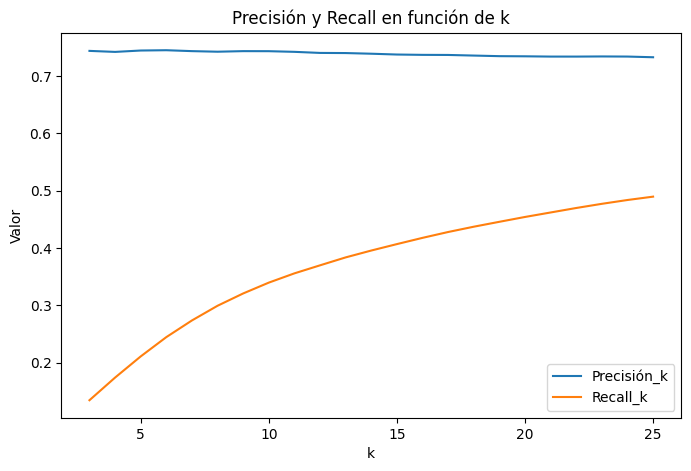

In [84]:
# 4. Curvas de Precisión y Recall vs k

k_values = range(3, 26)
prec_list, rec_list = [], []

for k in k_values:
    prec, rec = precision_recall_at_k(pred_svd, k=k, threshold=3.5)
    prec_list.append(sum(prec.values()) / len(prec))
    rec_list.append(sum(rec.values()) / len(rec))

plt.figure(figsize=(8,5))
plt.plot(k_values, prec_list, label='Precisión_k')
plt.plot(k_values, rec_list, label='Recall_k')
plt.xlabel('k')
plt.ylabel('Valor')
plt.title('Precisión y Recall en función de k')
plt.legend()
plt.show()

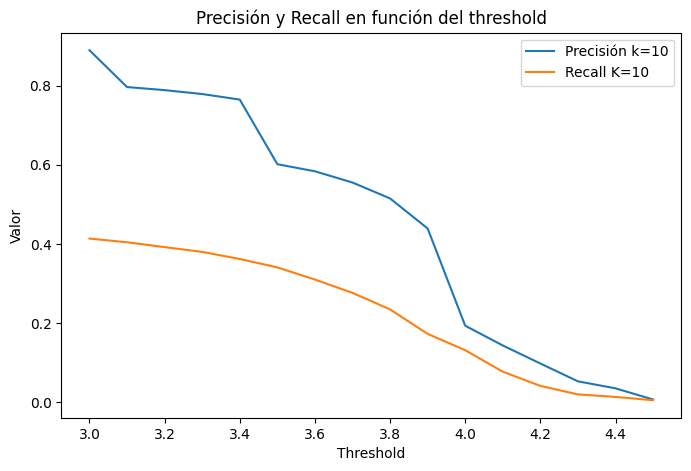

In [88]:
# 5. Curvas de Precisión y Recall vs threshold

thresholds = np.arange(3.0, 4.6, 0.1)
prec_thr, rec_thr = [], []

for t in thresholds:
    prec, rec = precision_recall_at_k(pred_svd, k=10, threshold=t)
    prec_thr.append(sum(prec.values()) / len(prec))
    rec_thr.append(sum(rec.values()) / len(rec))

plt.figure(figsize=(8,5))
plt.plot(thresholds, prec_thr, label='Precisión k=10')
plt.plot(thresholds, rec_thr, label='Recall K=10')
plt.xlabel('Threshold')
plt.ylabel('Valor')
plt.title('Precisión y Recall en función del threshold')
plt.legend()
plt.show()

In [89]:
# 6. Estimar ratings faltantes y generar matriz completa

# Crear una matriz usuario-producto con ratings predichos
usuarios = df_beers['userId'].unique()
cervezas = df_beers['beerId'].unique()

matriz_pred = pd.DataFrame(index=usuarios, columns=cervezas)

# Llenar la matriz con las predicciones del modelo SVD
for u in usuarios:
    for i in cervezas:
        matriz_pred.loc[u, i] = model_svd.predict(uid=u, iid=i).est

matriz_pred = matriz_pred.astype(float)

print("\nMatriz (usuario, producto) completada con ratings estimados:")
display(matriz_pred.head())


Matriz (usuario, producto) completada con ratings estimados:


,995,58695,4083,40310,1904,409,16858,25061,14309,13906,...,1145,708,45308,25095,4957,47589,62792,18432,4753,6428
144,3.871513,3.622858,3.842587,3.636771,3.919137,3.754595,3.686757,3.706330,3.722344,3.778792,...,3.657975,3.769330,3.695747,3.729386,3.764388,3.804747,3.440846,3.376007,3.698321,3.498709
63,4.131842,4.034455,4.233354,4.016627,4.262557,4.097508,4.041871,4.018054,3.997604,4.119530,...,3.955044,4.137833,4.080694,4.025308,4.143937,4.039100,3.805570,3.679589,4.081408,3.932017
147,3.979455,3.897711,4.086853,3.851518,4.112932,3.953385,3.885829,3.867270,3.852832,3.949128,...,3.797175,3.995989,3.943278,3.887667,4.008618,3.910191,3.680414,3.539807,3.943376,3.765250
4261,3.874472,3.820959,3.948819,3.655140,4.013410,3.713958,3.734862,3.843192,3.710188,3.799044,...,3.573084,3.878221,3.733281,3.613957,3.892369,3.604023,3.425362,3.360017,3.668916,3.689851
140,4.044295,3.965228,4.141565,3.924157,4.173485,4.014227,3.953092,3.921410,3.919040,4.011564,...,3.856818,4.048115,3.994935,3.954797,4.064306,3.969619,3.738268,3.591548,4.010203,3.831489


# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
